# Used Car Prices - EDA Assignment

This notebook explores the `car_prices.csv` dataset using pandas.
I load the data, clean it up, answer some questions about it, and make a few charts.

## Task 1: Data Ingestion & Quality Profiling

### 1.1 Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
# read the csv file into a dataframe
df = pd.read_csv('car_prices.csv')

# look at first 5 rows
df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [3]:
# data types and number of records
print("Number of records:", len(df))
df.dtypes

Number of records: 558837


year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object

### 1.2 Understanding the data structure

In [4]:
# shape of the dataset - (rows, columns)
df.shape

(558837, 16)

In [5]:
# column names
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='str')

In [6]:
# column names with their data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


### 1.3 Missing values and duplicates

In [7]:
# count of nulls in each column
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [9]:
# percentage of nulls in each column
(df.isnull().sum() / len(df) * 100).round(2)

year             0.00
make             1.84
model            1.86
trim             1.91
body             2.36
transmission    11.69
vin              0.00
state            0.00
condition        2.12
odometer         0.02
color            0.13
interior         0.13
seller           0.00
mmr              0.01
sellingprice     0.00
saledate         0.00
dtype: float64

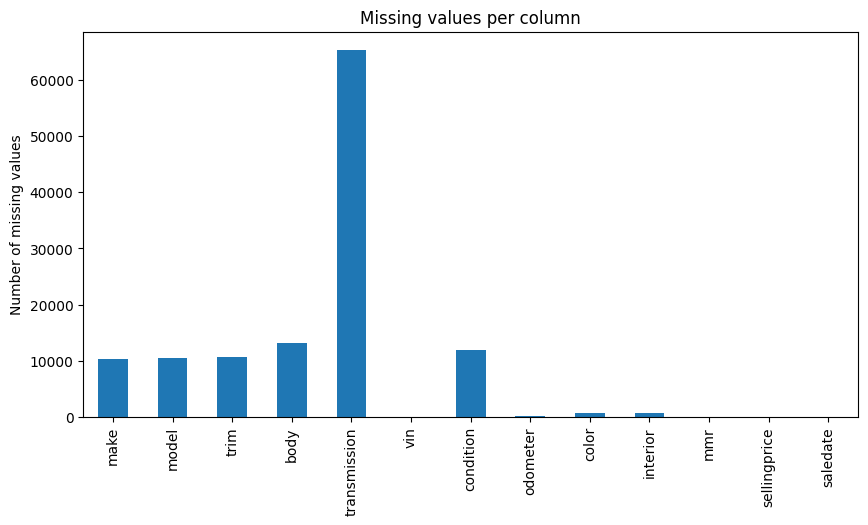

In [10]:
# quick bar chart of null counts, only for columns that actually have nulls
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

plt.figure(figsize=(10,5))
null_counts.plot(kind='bar')
plt.ylabel('Number of missing values')
plt.title('Missing values per column')
plt.show()

**How I am handling the nulls:**
- For text/category columns (make, model, trim, body, color, interior, transmission) - fill missing values with `'Unknown'`. There aren't many missing and they are not numbers, so I can't take an average.
- For number columns (condition, odometer, mmr) - fill with the median, since it is not affected much by outliers.
- For rows where price, VIN or sale date is missing, I just drop those rows since there are very few of them and they are hard to guess.

In [11]:
# fill missing categorical columns with 'Unknown'
cat_cols = ['make', 'model', 'trim', 'body', 'color', 'interior', 'transmission']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

# fill missing numeric columns with median
num_cols = ['condition', 'odometer', 'mmr']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# drop rows where important columns are still missing
df = df.dropna(subset=['sellingprice', 'vin', 'saledate', 'state'])

# check nulls again
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

In [12]:
# check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (558821, 16)


## Task 2: DataFrame Queries

### 2.1 Average, minimum and maximum selling price

In [13]:
print("Average price:", df['sellingprice'].mean())
print("Minimum price:", df['sellingprice'].min())
print("Maximum price:", df['sellingprice'].max())

Average price: 13611.358175515952
Minimum price: 1.0
Maximum price: 230000.0


### 2.2 Unique colors of cars

In [14]:
colors = df['color'].unique()
print("Number of unique colors:", len(colors))
print(colors)

Number of unique colors: 43
<StringArray>
[    'white',      'gray',     'black',       'red',    'silver',      'blue',
     'brown',     'beige',    'purple',  'burgundy',         '—',      'gold',
    'yellow',     'green',  'charcoal',   'Unknown',    'orange', 'off-white',
 'turquoise',      'pink',      'lime',      '4802',      '9410',      '1167',
      '2172',     '14872',     '12655',     '15719',      '6388',     '16633',
     '11034',      '6864',       '339',     '18384',      '9887',      '9837',
     '20627',       '721',      '6158',      '5705',     '18561',      '2846',
      '5001']
Length: 43, dtype: str


### 2.3 Number of unique car brands and models

In [15]:
print("Unique brands:", df['make'].nunique())
print("Unique models:", df['model'].nunique())

Unique brands: 97
Unique models: 974


### 2.4 Cars with selling price greater than $165,000

In [16]:
expensive_cars = df[df['sellingprice'] > 165000]
print("Number of cars:", len(expensive_cars))
expensive_cars

Number of cars: 7


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


### 2.5 Top 5 most frequently sold car models

In [17]:
df['model'].value_counts().head(5)

model
Altima    19349
F-150     14479
Fusion    12945
Camry     12545
Escape    11861
Name: count, dtype: int64

### 2.6 Average selling price by brand (make)

In [18]:
df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)

make
Rolls-Royce    153488.235294
Ferrari        127210.526316
Lamborghini    112625.000000
Bentley         74367.672414
airstream       71000.000000
                   ...      
dodge tk          550.000000
Geo               528.947368
dot               500.000000
ford truck        483.333333
Daewoo            400.000000
Name: sellingprice, Length: 97, dtype: float64

### 2.7 Minimum selling price for each interior

In [19]:
df.groupby('interior')['sellingprice'].min().sort_values()

interior
black           1.0
gray            1.0
beige         100.0
green         100.0
tan           100.0
silver        150.0
blue          150.0
—             150.0
burgundy      175.0
red           200.0
brown         200.0
purple        200.0
Unknown       225.0
gold          250.0
white         350.0
off-white     900.0
orange       1200.0
yellow       3100.0
Name: sellingprice, dtype: float64

### 2.8 Highest odometer reading per year (high to low)

In [20]:
df.groupby('year')['odometer'].max().sort_values(ascending=False)

year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64

### 2.9 New column for car age (assuming current year is 2025)

In [24]:
df['car_age'] = 2025 - df['year']
df[['year', 'car_age']].head(3)

,year,car_age
0,2015,10
1,2015,10
2,2014,11


### 2.10 Cars with condition >= 48 and odometer > 90,000

In [25]:
filtered = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
print("Number of cars:", len(filtered))
filtered.head(3)

Number of cars: 746


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,car_age
3230,2008,HUMMER,H3,Base,SUV,automatic,5gten13e588135632,ca,48.0,91132.0,black,beige,apexcars net,11950.0,15300.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST),17
3767,2006,Chevrolet,Silverado 1500,LS2,Crew Cab,automatic,2gcec13v561250941,ca,49.0,97742.0,white,gray,coast sports cars inc,8800.0,13250.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),19
4365,2005,Toyota,4Runner,SR5,SUV,automatic,jtebu14rx50077814,ca,48.0,155887.0,gray,gray,san diego sports cars,6850.0,9500.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),20


### 2.11 Which state has higher prices for newer cars (year > 2013)?

In [28]:
newer_cars = df[df['year'] > 2013]
state_avg = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)
state_avg.head(5)

state
oh    28020.221053
ab    25204.255319
nj    24237.063973
on    22962.560386
qc    22722.938144
Name: sellingprice, dtype: float64

In [29]:
print("State with the highest average price for newer cars:", state_avg.index[0])

State with the highest average price for newer cars: oh


### 2.12 For excellent condition cars (top 20%), which makes have the lowest average price?

In [30]:
# find the condition score that separates the top 20%
threshold = df['condition'].quantile(0.80)
print("Condition score for top 20%:", threshold)

excellent_cars = df[df['condition'] >= threshold]
excellent_cars.groupby('make')['sellingprice'].mean().sort_values().head(10)

Condition score for top 20%: 43.0


make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
chrysler      6225.000000
smart         6835.759494
mazda         7275.000000
Pontiac       7686.824324
Saab          7711.111111
Name: sellingprice, dtype: float64

## Task 3: Data Visualization and Insights

### 3.1 Correlation of numerical features

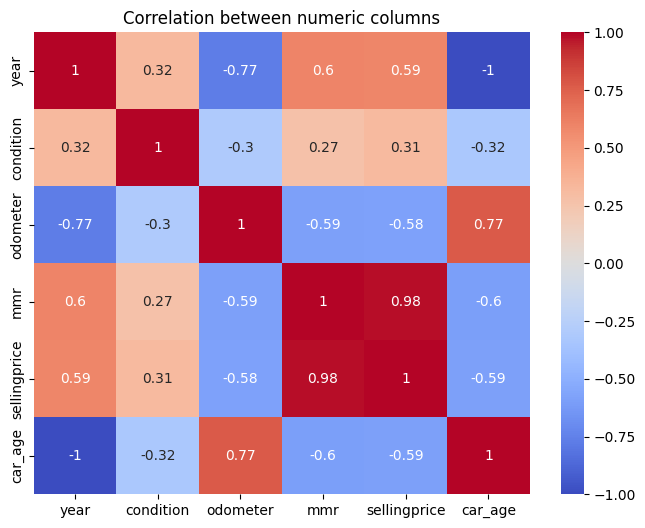

In [31]:
num_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice', 'car_age']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between numeric columns')
plt.show()

**Insight:** `sellingprice` and `mmr` move almost exactly together, which makes sense since `mmr` is basically an estimated market price. `odometer` and `car_age` have a negative relation with price - older, higher mileage cars sell for less.

### 3.2 Average selling price by year

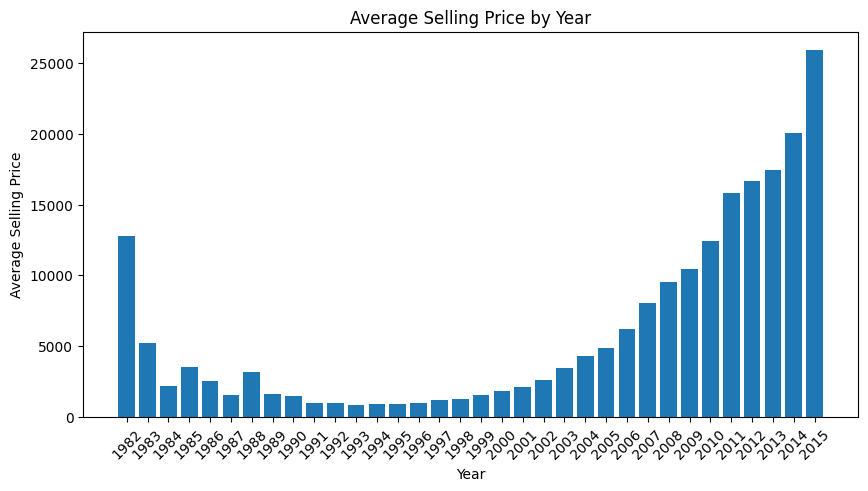

In [32]:
avg_price_by_year = df.groupby('year')['sellingprice'].mean()

plt.figure(figsize=(10,5))
plt.bar(avg_price_by_year.index.astype(str), avg_price_by_year.values)
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Year')
plt.xticks(rotation=45)
plt.show()

**Which plot - bar or scatter?** I used a bar chart because `year` has a limited number of distinct values and I am comparing one average value (price) per year. Bar charts are good for comparing values across categories like this.

**Pattern:** newer cars generally sell for more money. This makes sense because cars lose value as they age.

### 3.3 Average selling price by odometer

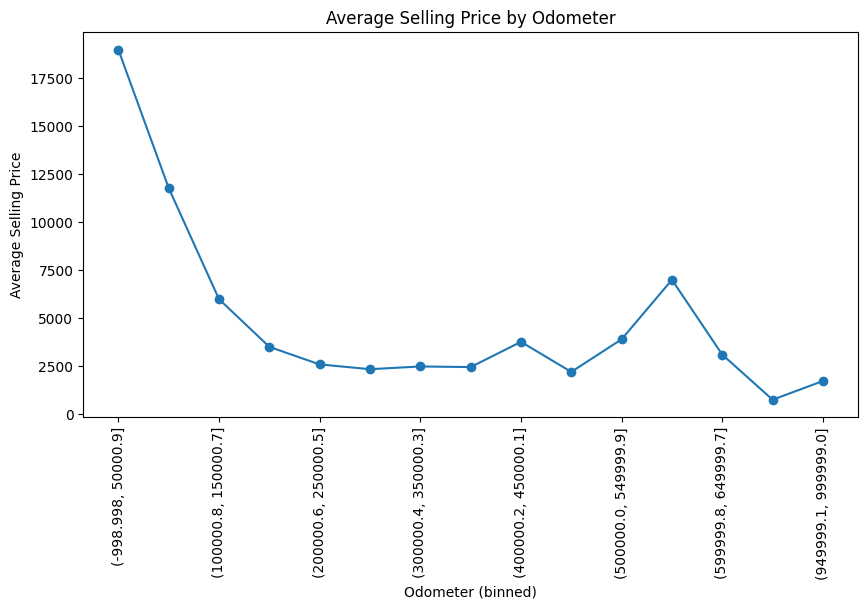

In [33]:
# odometer has a lot of different values, so I'll group it into bins first
df['odometer_bin'] = pd.cut(df['odometer'], bins=20)
avg_price_by_odo = df.groupby('odometer_bin', observed=True)['sellingprice'].mean()

plt.figure(figsize=(10,5))
avg_price_by_odo.plot(kind='line', marker='o')
plt.xlabel('Odometer (binned)')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Odometer')
plt.xticks(rotation=90)
plt.show()

**Trend:** as odometer reading goes up, average selling price goes down. This is expected - cars with more miles on them are usually older and more worn out, so they sell for less.

### 3.4 Number of cars sold in each state

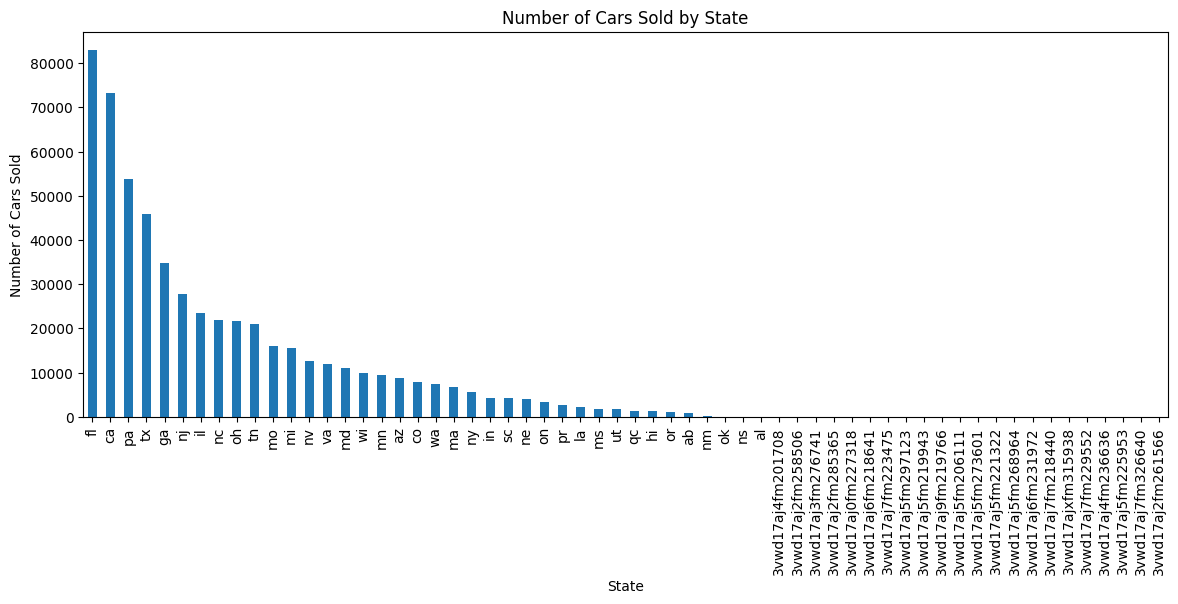

Top 3 states:
state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


In [34]:
cars_by_state = df['state'].value_counts()

plt.figure(figsize=(14,5))
cars_by_state.plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.title('Number of Cars Sold by State')
plt.show()

print("Top 3 states:")
print(cars_by_state.head(3))

**Insight:** a few states account for most of the sales. This is probably because that's where the big car auctions/dealers are, not just because those states have more people.

### 3.5 Average selling price by condition score (bins of size 5)

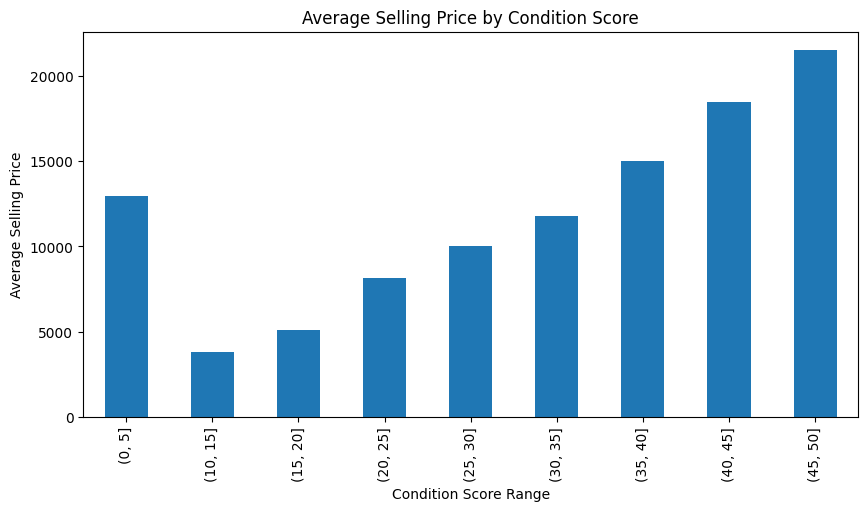

In [35]:
bins = list(range(0, 55, 5))
df['condition_bin_5'] = pd.cut(df['condition'], bins=bins)

avg_price_by_cond5 = df.groupby('condition_bin_5', observed=True)['sellingprice'].mean()

plt.figure(figsize=(10,5))
avg_price_by_cond5.plot(kind='bar')
plt.xlabel('Condition Score Range')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Condition Score')
plt.show()

**Insight:** the average price goes up as the condition score goes up. Cars in the best condition bracket sell for a lot more than cars in the worst bracket.

### 3.6 Number of cars sold by condition ranges (bins of size 10)

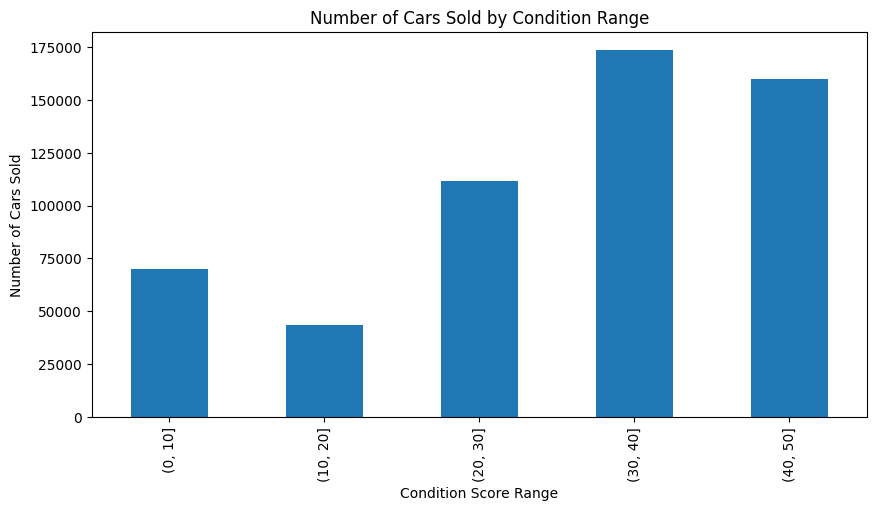

In [36]:
bins10 = list(range(0, 60, 10))
df['condition_bin_10'] = pd.cut(df['condition'], bins=bins10)

count_by_cond10 = df.groupby('condition_bin_10', observed=True).size()

plt.figure(figsize=(10,5))
count_by_cond10.plot(kind='bar')
plt.xlabel('Condition Score Range')
plt.ylabel('Number of Cars Sold')
plt.title('Number of Cars Sold by Condition Range')
plt.show()

**Insight:** most cars fall in the middle condition ranges. Very few cars are in really poor or perfect condition - most are just average.

### 3.7 Box plot: selling price by color

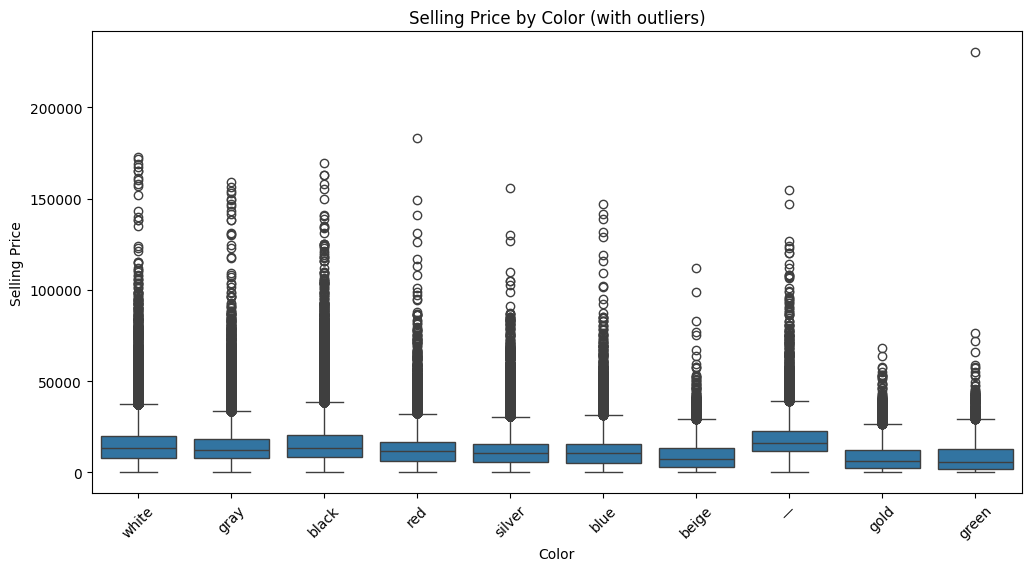

In [38]:
# only look at the 10 most common colors so the plot isn't too crowded
top_colors = df['color'].value_counts().head(10).index
df_top_colors = df[df['color'].isin(top_colors)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_colors, x='color', y='sellingprice')
plt.xlabel('Color')
plt.ylabel('Selling Price')
plt.title('Selling Price by Color (with outliers)')
plt.xticks(rotation=45)
plt.show()

**Insight:** there are a lot of outliers (expensive cars) in every color, which makes the boxes hard to compare. Let's remove the outliers and plot again.

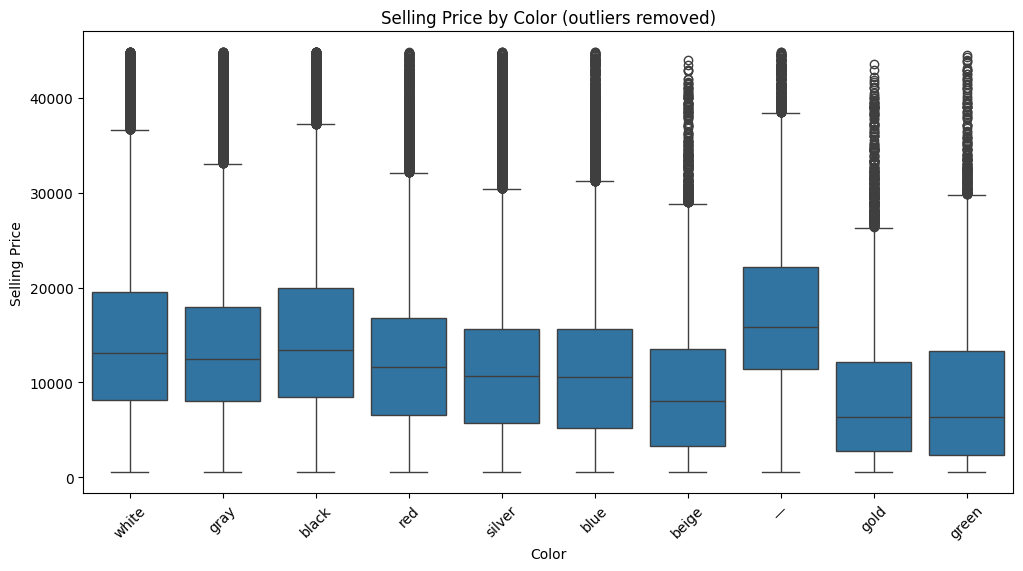

In [39]:
# remove outliers using the 1st and 99th percentile as cutoffs
low = df_top_colors['sellingprice'].quantile(0.01)
high = df_top_colors['sellingprice'].quantile(0.99)

df_no_outliers = df_top_colors[(df_top_colors['sellingprice'] >= low) & (df_top_colors['sellingprice'] <= high)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_no_outliers, x='color', y='sellingprice')
plt.xlabel('Color')
plt.ylabel('Selling Price')
plt.title('Selling Price by Color (outliers removed)')
plt.xticks(rotation=45)
plt.show()

**Insight after removing outliers:** the price ranges look a lot more similar across colors now. Black, white and silver cars seem to have a slightly higher median price than the more unusual colors, maybe because they're more common on nicer/luxury cars.

## Conclusion

Overall, newer cars, cars with lower mileage, and cars in better condition tend to sell for higher prices. A small number of states account for most of the car sales in the dataset. Car color doesn't seem to make a huge difference in price once outliers are removed, though neutral colors like black and white sell for slightly more on average.